# Target (what we predict)

#  Churn

* Yes = customer leaves
* No = stays

# importing libraries

In [64]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
df=pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [66]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [67]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

# DATA CLEANING

In [68]:
 df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [69]:
 df.info()
# TotalCharges has 7032 non-null, not 7043
# That means 11 missing values (NaN) are hiding

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [70]:
 df.dropna(inplace=True)

In [71]:
df.info()
# now we have only those rows where total charges is not zero
# from rows 7043 to 7032 now


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Drop useless column

In [72]:
 df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [73]:
 df.drop('customerID', axis=1, inplace=True,errors='ignore')
# If exists → remove
# If not → ignore (no error)

# Convert target(churn yes:1,no:0)

In [74]:
df['Churn']=df['Churn'].map({'Yes':1,'No':0})

In [75]:
#df.info()
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [76]:
df = pd.get_dummies(df, drop_first=True)

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Columns: 6560 entries, SeniorCitizen to TotalCharges_999.9
dtypes: bool(6556), float64(1), int64(3)
memory usage: 44.2 MB


# Train/Test Split 

In [78]:
from sklearn.model_selection import train_test_split

X=df.drop('Churn',axis=1)# inputs
y = df['Churn'] # output

X_train, X_test, y_train, y_test =train_test_split(
    X,y,test_size=0.2,random_state=42
)
# X → all columns except churn (features)
# y → churn (what we predict)
# Train → learning data 
# Test → testing data 

#  We train on 80% and test on 20%

In [79]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# NOTES
# KEYWORDS MEANING:
**from sklearn.preprocessing import StandardScaler**
> from → take something from a library
sklearn → machine learning toolkit
preprocessing → “prepare data before training”
StandardScaler → tool that makes numbers fair (same scale)
👉 Simple idea:
It converts data so everything is on similar range.


**scaler = StandardScaler()**
> scaler → a tool object you created
StandardScaler() → ready-made machine
👉 Think:
“I created a machine that will normalize my data”

**X_train = scaler.fit_transform(X_train)**
> X_train → training input data
scaler → scaling tool
fit → learn pattern (mean + standard deviation)
transform → apply scaling
👉 Full meaning:
“Learn data pattern from training set, then convert it into scaled form”

**X_test = scaler.transform(X_test)**
> ❌ NOT fit again
✅ only transform
👉 Meaning:
“Use same learned scaling rules on test data”
💡 Why?
Because test data must behave like training data.


# Train Model (Logistic Regression)

In [80]:
model = LogisticRegression(max_iter=5000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
# Classification Report
# Precision → how correct predictions are
# Recall → how many real churns found
# F1-score → balance of both

Accuracy: 0.7799858055358411
[[889 147]
 [163 210]]
              precision    recall  f1-score   support

           0       0.85      0.86      0.85      1036
           1       0.59      0.56      0.58       373

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409



**model = LogisticRegression(max_iter=5000, class_weight='balanced')**
> model → your AI brain
LogisticRegression → algorithm for YES/NO prediction
max_iter=5000
max_iter → maximum learning steps
5000 → allow more time to learn (fixes convergence warning)
class_weight='balanced'
tells model:
“treat both classes equally (stay vs churn)”
👉 Simple meaning:
“Build a smart AI that doesn’t ignore rare churn customers”

**model.fit(X_train, y_train)**
> X_train → inputs
y_train → correct answers
👉 Meaning:
“Train model using questions + correct answers”

**y_pred = model.predict(X_test)**
> predict → guess output
X_test → new unseen data
y_pred → predicted answers
👉 Meaning:
“Model guesses churn for new customers”

**accuracy_score(y_test, y_pred)**
> “Compare real vs predicted and calculate % correct”

**confusion_matrix(y_test, y_pred)**
> builds a table:
True Positives (correct churn)
True Negatives (correct stay)
False Positives (wrong alarm)
False Negatives (missed churn)
👉 Simple idea:
“Who did model get right and wrong?

**classification_report(y_test, y_pred)**
> Precision → how many predicted churn are actually churn
Recall → how many real churn were found
F1-score → balance of precision + recall
Support → total samples
👉 Simple meaning:
“Deep performance report of model”

# IMPROVE MODEL


# Goal: Catch MORE churn customers


# STEP 1: Try Decision Tree

In [81]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [82]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.8076650106458482
[[966  70]
 [201 172]]
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      1036
           1       0.71      0.46      0.56       373

    accuracy                           0.81      1409
   macro avg       0.77      0.70      0.72      1409
weighted avg       0.80      0.81      0.79      1409



# STEP 2: Try Random Forest 

In [83]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [84]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7998580553584103
[[959  77]
 [205 168]]
              precision    recall  f1-score   support

           0       0.82      0.93      0.87      1036
           1       0.69      0.45      0.54       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.79      0.80      0.78      1409



# Comparision b/w models

* Missing a churn customer = LOSS 
* So we prefer recall > accuracy

| Model                                   | Accuracy | Churn Recall | Verdict               |
| --------------------------------------- | -------- | ------------ | --------------------- |
| Random Forest                           | 78.5%    | 0.48 or 48%       | Not good for business |
| Decision Tree                           | 77.5%    | 0.59 or 59%       | Medium                |
| Logistic Regression (Balanced + Scaled) | 73%      | 0.79 or 79%   |  BEST               |


# BEST model = Logistic Regression (with scaling + class_weight='balanced')

Because:

It finds MOST churn customers
That is the REAL goal of this project

# Visualization(Extra)

# Churn Distribution

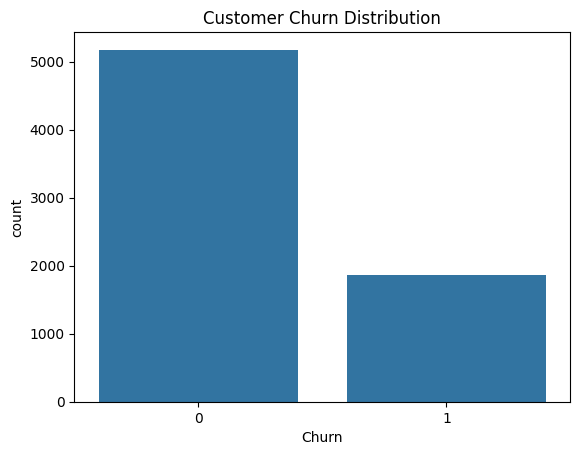

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)#Shows how many customers stayed vs left
plt.title("Customer Churn Distribution")
plt.show()

# Monthly Charges vs Churn

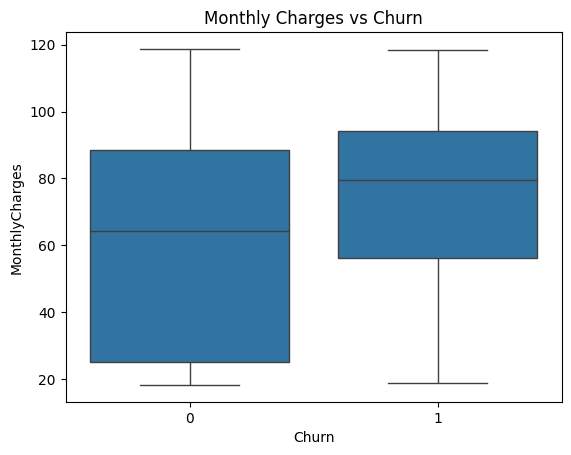

In [86]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)#Check if high bill customers leave more
plt.title("Monthly Charges vs Churn")
plt.show()

# Tenure vs Churn

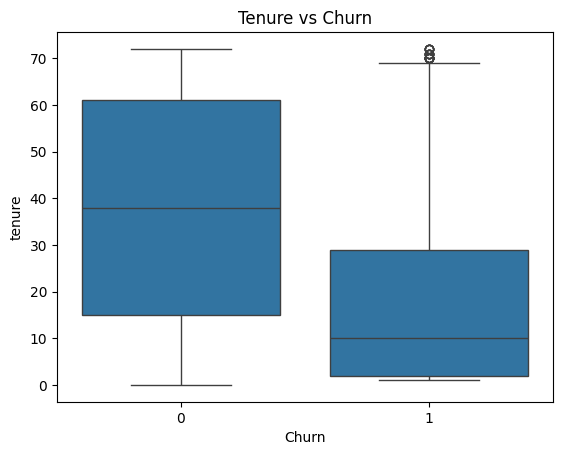

In [87]:
sns.boxplot(x='Churn', y='tenure', data=df)#New customers are more likely to leave
plt.title("Tenure vs Churn")
plt.show()

# FEATURE IMPORTANCE 
> Shows WHICH factors cause churn most
* Example:
Contract type,
Monthly charges, 
Tenure

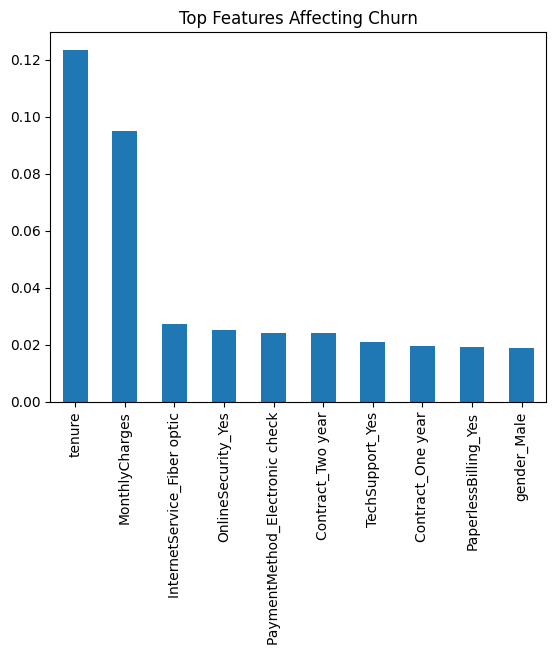

In [88]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Features Affecting Churn")
plt.show()

# Summary:
I worked on a classification problem where the goal was to predict customer churn. I performed data cleaning, encoding, and scaling. I trained multiple models and optimized recall because business priority was identifying customers likely to leave. Logistic Regression performed best in detecting churn customers.